# ⭐ Day 8: Modules, Packages & Virtual Environments  
Organizing Code for Larger AI & ML Projects | Step-by-Step Tutorial with Examples & Exercises

*Day 8 of 369-day Python & AI Learning Path* 💡

## Introduction: Why Organization Matters in AI/ML

As you progress from writing simple scripts to building real-world AI and machine learning systems, you'll quickly discover that **organization is everything**. A typical ML project involves data preprocessing pipelines, custom neural network layers, training loops, evaluation metrics, configuration files, and utility functions—often spanning thousands of lines of code.

Without proper structure, your projects become **nightmares to maintain**: you'll find yourself copying and pasting the same preprocessing functions between notebooks, struggling to reproduce results, or breaking working code when making small changes. This is where **modules**, **packages**, and **virtual environments** become your best friends.

Modules allow you to split your code into logical, reusable files. Packages let you organize these modules into hierarchical structures. Virtual environments ensure that each project has its own isolated dependencies, preventing version conflicts between different projects. Together, these tools transform your messy scripts into **professional, shareable, and scalable** AI/ML projects that colleagues can actually understand and use.

By the end of this tutorial, you'll know how to structure a proper ML project, create reusable utility modules, manage dependencies with `requirements.txt`, and set up isolated environments—skills that separate hobbyists from professional ML engineers. Let's dive in! 🚀

## 📌 Table of Contents

1. [What is a Module?](#what-is-a-module)
2. [The `__name__ == "__main__"` Guard](#the-name-guard)
3. [Creating Packages with `__init__.py`](#creating-packages)
4. [Standard Library Modules for AI](#standard-library)
5. [Installing Third-Party Packages](#third-party-packages)
6. [Virtual Environments](#virtual-environments)
7. [AI/ML Project Structure Best Practices](#project-structure)
8. [Practical Example: Building an `ai_utils` Package](#practical-example)
9. [Running Scripts from Command Line](#command-line)
10. [🛠️ Hands-On Exercises](#exercises)
11. [Solutions](#solutions)

## 1. What is a Module? <a name="what-is-a-module"></a>

A **module** is simply a Python file (`.py`) containing definitions and statements. It allows you to logically organize your code and reuse it across different parts of your project.

### Creating and Importing Modules

You can import modules in several ways:

In [ ]:
# Method 1: Import the entire module
import os
print(f"Current directory: {os.getcwd()}")

# Method 2: Import specific functions/variables
from math import sqrt, pi
print(f"Square root of 16: {sqrt(16)}")
print(f"Value of pi: {pi}")

# Method 3: Import with an alias (common in data science!)
import matplotlib.pyplot as plt
import numpy as np

# Method 4: Import all (generally NOT recommended - pollutes namespace)
# from math import *  # Avoid this in production code!

Current directory: d:\artificial intelligence\008_ai
Square root of 16: 4.0
Value of pi: 3.141592653589793


## 2. The `__name__ == "__main__"` Guard <a name="the-name-guard"></a>

When a Python file is run directly, Python sets `__name__` to `"__main__"`. When imported as a module, `__name__` is set to the module name. This guard prevents code from running when the module is imported:

In [2]:
# This code demonstrates the concept (imagine this is in a file called 'my_module.py')

def preprocess_data(data):
    """Clean and normalize data."""
    return [x * 2 for x in data if x is not None]

def main():
    """Main execution function - only runs when script is executed directly."""
    test_data = [1, 2, None, 4, 5]
    result = preprocess_data(test_data)
    print(f"Test data: {test_data}")
    print(f"Processed: {result}")

# This guard ensures main() only runs when the file is executed directly
# NOT when it's imported as a module
if __name__ == "__main__":
    main()
    print(f"\nRunning as main program: __name__ = {__name__}")
else:
    print(f"Imported as module: __name__ = {__name__}")

Test data: [1, 2, None, 4, 5]
Processed: [2, 4, 8, 10]

Running as main program: __name__ = __main__


## 3. Creating Packages with `__init__.py` <a name="creating-packages"></a>

A **package** is a directory containing Python modules and a special file called `__init__.py`. The `__init__.py` can be empty or contain initialization code.

### Package Structure Example:
```
my_ml_project/
├── __init__.py          # Makes this a package
├── data/
│   ├── __init__.py
│   └── loaders.py       # Data loading functions
├── models/
│   ├── __init__.py
│   └── neural_nets.py   # Model definitions
└── utils/
    ├── __init__.py
    └── viz.py           # Visualization tools
```

In [3]:
# Simulating package imports (in practice, these would be separate .py files)

# Relative imports (within a package)
# from . import module        # Import module from same package
# from .. import parent       # Import from parent package
# from .data import loaders   # Import specific submodule

# The __all__ variable in __init__.py controls what gets imported with 'from package import *'
# __all__ = ['module1', 'module2']  # List of modules to import with *

## 4. Standard Library Modules for AI <a name="standard-library"></a>

Python's standard library provides powerful tools essential for AI/ML workflows:

In [4]:
import os
import sys
import datetime
import math
import random
import collections
import itertools

# os - Operating system interface (file paths, environment variables)
print("📁 OS Module Examples:")
print(f"Current working directory: {os.getcwd()}")
print(f"Environment variable PATH exists: {'PATH' in os.environ}")

# datetime - Date and time manipulation (crucial for logging experiments)
print("\n⏰ Datetime Examples:")
timestamp = datetime.datetime.now()
print(f"Current timestamp: {timestamp}")
print(f"Formatted: {timestamp.strftime('%Y-%m-%d_%H-%M-%S')}")

# Random - Random number generation (data augmentation, splitting datasets)
print("\n🎲 Random Examples:")
random.seed(42)  # For reproducibility!
print(f"Random sample from list: {random.sample([1, 2, 3, 4, 5], 3)}")
print(f"Random float: {random.random():.4f}")

# collections - Specialized container datatypes
print("\n📊 Collections Examples:")
from collections import Counter, defaultdict
labels = ['cat', 'dog', 'cat', 'bird', 'cat', 'dog']
label_counts = Counter(labels)
print(f"Label distribution: {dict(label_counts)}")

# defaultdict for automatic initialization
metrics = defaultdict(list)
metrics['accuracy'].append(0.95)
metrics['loss'].append(0.12)
print(f"Metrics dictionary: {dict(metrics)}")

# itertools - Efficient looping and combinatorics
print("\n🔄 Itertools Examples:")
from itertools import cycle, islice
augmentation_ops = cycle(['flip', 'rotate', 'zoom', 'brightness'])
print(f"Next 5 augmentation operations: {list(islice(augmentation_ops, 5))}")

📁 OS Module Examples:
Current working directory: d:\artificial intelligence\008_ai
Environment variable PATH exists: True

⏰ Datetime Examples:
Current timestamp: 2026-03-25 06:35:56.128604
Formatted: 2026-03-25_06-35-56

🎲 Random Examples:
Random sample from list: [1, 5, 3]
Random float: 0.2750

📊 Collections Examples:
Label distribution: {'cat': 3, 'dog': 2, 'bird': 1}
Metrics dictionary: {'accuracy': [0.95], 'loss': [0.12]}

🔄 Itertools Examples:
Next 5 augmentation operations: ['flip', 'rotate', 'zoom', 'brightness', 'flip']


## 5. Installing Third-Party Packages <a name="third-party-packages"></a>

The Python Package Index (PyPI) hosts thousands of packages essential for AI/ML:

In [5]:
# Common installation commands (run these in terminal, not typically in notebooks)
# !pip install numpy pandas scikit-learn matplotlib tensorflow torch

# In Jupyter, you can use ! to run shell commands:
# !pip list  # Show installed packages

# Checking if packages are available (commented out to avoid dependency issues)
try:
    import numpy as np
    print(f"✅ NumPy version: {np.__version__}")
except ImportError:
    print("❌ NumPy not installed")

try:
    import pandas as pd
    print(f"✅ Pandas version: {pd.__version__}")
except ImportError:
    print("❌ Pandas not installed")

✅ NumPy version: 2.2.6
✅ Pandas version: 3.0.0


### Creating requirements.txt

The `requirements.txt` file lists all dependencies with specific versions, ensuring reproducibility:

In [6]:
# Example requirements.txt content (save this to a file)
requirements_content = """
# Data manipulation
numpy>=1.21.0
pandas>=1.3.0

# Machine Learning
scikit-learn>=1.0.0

# Deep Learning (choose one or both)
# tensorflow>=2.8.0
# torch>=1.11.0

# Visualization
matplotlib>=3.5.0
seaborn>=0.11.0

# Utilities
tqdm>=4.62.0          # Progress bars
pyyaml>=6.0           # YAML config files
python-dotenv>=0.20.0 # Environment variables
"""

print("📋 Sample requirements.txt content:")
print(requirements_content)

# To generate requirements.txt from current environment:
# !pip freeze > requirements.txt

# To install from requirements.txt:
# !pip install -r requirements.txt

📋 Sample requirements.txt content:

# Data manipulation
numpy>=1.21.0
pandas>=1.3.0

# Machine Learning
scikit-learn>=1.0.0

# Deep Learning (choose one or both)
# tensorflow>=2.8.0
# torch>=1.11.0

# Visualization
matplotlib>=3.5.0
seaborn>=0.11.0

# Utilities
tqdm>=4.62.0          # Progress bars
pyyaml>=6.0           # YAML config files
python-dotenv>=0.20.0 # Environment variables



## 6. Virtual Environments <a name="virtual-environments"></a>

Virtual environments create isolated Python environments, preventing dependency conflicts between projects.

### Why They Matter for AI/ML:
- 🧪 **Experiment isolation**: Test different TensorFlow/PyTorch versions
- 🤝 **Collaboration**: Share exact dependency versions with teammates
- 🏭 **Production**: Deploy with known, tested dependencies
- 🔄 **Reproducibility**: Ensure results are reproducible across machines

In [7]:
# Virtual Environment Commands (run in terminal)

# Creating a virtual environment
# python -m venv myenv

# Activating (Linux/Mac):
# source myenv/bin/activate

# Activating (Windows):
# myenv\Scripts\activate

# Deactivating:
# deactivate

# Checking which Python is being used
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Checking current environment (if using conda or venv)
import os
if 'CONDA_DEFAULT_ENV' in os.environ:
    print(f"Conda environment: {os.environ['CONDA_DEFAULT_ENV']}")
elif hasattr(sys, 'real_prefix') or (hasattr(sys, 'base_prefix') and sys.base_prefix != sys.prefix):
    print(f"Virtual environment active: {sys.prefix}")
else:
    print("Using system Python (no virtual environment active)")

Python executable: c:\Users\786\miniconda3\envs\env_dl\python.exe
Python version: 3.13.0 | packaged by Anaconda, Inc. | (main, Oct  7 2024, 21:21:52) [MSC v.1929 64 bit (AMD64)]
Conda environment: env_dl


## 7. AI/ML Project Structure Best Practices <a name="project-structure"></a>

A well-organized project structure makes your code maintainable and shareable:

In [8]:
# Displaying recommended project structure
project_structure = """
my_ml_project/
├── README.md                 # Project description and setup instructions
├── requirements.txt          # Python dependencies
├── setup.py                 # Package installation configuration
├── .gitignore               # Files to ignore in version control
├── .env.example             # Template for environment variables
│
├── data/                    # Data directory (usually gitignored)
│   ├── raw/                 # Original, immutable data
│   ├── processed/           # Cleaned data ready for modeling
│   └── external/            # Data from third party sources
│
├── notebooks/               # Jupyter notebooks
│   ├── 01_eda.ipynb         # Exploratory Data Analysis
│   ├── 02_preprocessing.ipynb
│   └── 03_modeling.ipynb
│
├── src/                     # Source code (your modules/packages)
│   ├── __init__.py
│   ├── data/                # Data loading and preprocessing
│   │   ├── __init__.py
│   │   ├── loaders.py
│   │   └── preprocessors.py
│   ├── models/              # Model definitions
│   │   ├── __init__.py
│   │   └── neural_networks.py
│   ├── features/            # Feature engineering
│   │   └── build_features.py
│   └── utils/               # Utility functions
│       ├── __init__.py
│       ├── viz.py           # Visualization
│       └── metrics.py       # Evaluation metrics
│
├── configs/                 # Configuration files (YAML/JSON)
│   ├── model_config.yaml
│   └── training_config.yaml
│
├── models/                  # Saved model artifacts (gitignored)
│   └── trained_models/
│
├── logs/                    # Training logs and tensorboard logs
│
└── tests/                   # Unit tests
    ├── test_data.py
    └── test_models.py
"""

print(project_structure)

# Creating this structure programmatically
import os

def create_project_structure(base_path="my_ml_project"):
    """Create a standard ML project directory structure."""
    dirs = [
        f"{base_path}/data/raw",
        f"{base_path}/data/processed",
        f"{base_path}/notebooks",
        f"{base_path}/src/data",
        f"{base_path}/src/models",
        f"{base_path}/src/utils",
        f"{base_path}/configs",
        f"{base_path}/models/trained_models",
        f"{base_path}/logs",
        f"{base_path}/tests"
    ]
    
    for dir_path in dirs:
        os.makedirs(dir_path, exist_ok=True)
        # Create __init__.py in Python package directories
        if 'src/' in dir_path and dir_path != f"{base_path}/src":
            init_file = os.path.join(dir_path, "__init__.py")
            if not os.path.exists(init_file):
                open(init_file, 'w').close()
    
    print(f"✅ Created project structure at: {os.path.abspath(base_path)}")

# Uncomment to create the structure:
# create_project_structure()


my_ml_project/
├── README.md                 # Project description and setup instructions
├── requirements.txt          # Python dependencies
├── setup.py                 # Package installation configuration
├── .gitignore               # Files to ignore in version control
├── .env.example             # Template for environment variables
│
├── data/                    # Data directory (usually gitignored)
│   ├── raw/                 # Original, immutable data
│   ├── processed/           # Cleaned data ready for modeling
│   └── external/            # Data from third party sources
│
├── notebooks/               # Jupyter notebooks
│   ├── 01_eda.ipynb         # Exploratory Data Analysis
│   ├── 02_preprocessing.ipynb
│   └── 03_modeling.ipynb
│
├── src/                     # Source code (your modules/packages)
│   ├── __init__.py
│   ├── data/                # Data loading and preprocessing
│   │   ├── __init__.py
│   │   ├── loaders.py
│   │   └── preprocessors.py
│   ├── models/   

## 8. Practical Example: Building an `ai_utils` Package <a name="practical-example"></a>

Let's create a practical example of a utility package for data preprocessing and visualization:

In [9]:
# Simulating the contents of ai_utils/preprocessing.py
# In practice, this would be in a separate file!

class DataPreprocessor:
    """Utility class for common data preprocessing tasks in ML."""
    
    @staticmethod
    def normalize(data, method='minmax'):
        """Normalize data to [0, 1] range or zero mean, unit variance."""
        if method == 'minmax':
            min_val = min(data)
            max_val = max(data)
            return [(x - min_val) / (max_val - min_val) for x in data]
        elif method == 'zscore':
            mean = sum(data) / len(data)
            std = (sum((x - mean) ** 2 for x in data) / len(data)) ** 0.5
            return [(x - mean) / std for x in data]
    
    @staticmethod
    def remove_outliers(data, threshold=2):
        """Remove outliers using Z-score method."""
        mean = sum(data) / len(data)
        std = (sum((x - mean) ** 2 for x in data) / len(data)) ** 0.5
        return [x for x in data if abs((x - mean) / std) < threshold]
    
    @staticmethod
    def train_test_split(X, y, test_ratio=0.2, random_seed=None):
        """Simple train/test split implementation."""
        if random_seed:
            import random
            random.seed(random_seed)
            indices = list(range(len(X)))
            random.shuffle(indices)
            X = [X[i] for i in indices]
            y = [y[i] for i in indices]
        
        split_idx = int(len(X) * (1 - test_ratio))
        return X[:split_idx], X[split_idx:], y[:split_idx], y[split_idx:]

# Testing our preprocessor
preprocessor = DataPreprocessor()

# Sample data
raw_data = [10, 20, 30, 40, 50, 1000]  # 1000 is an outlier
clean_data = preprocessor.remove_outliers(raw_data)
normalized = preprocessor.normalize(clean_data)

print("🧹 Preprocessing Results:")
print(f"Original: {raw_data}")
print(f"After outlier removal: {clean_data}")
print(f"After normalization: {[round(x, 3) for x in normalized]}")

🧹 Preprocessing Results:
Original: [10, 20, 30, 40, 50, 1000]
After outlier removal: [10, 20, 30, 40, 50]
After normalization: [0.0, 0.25, 0.5, 0.75, 1.0]


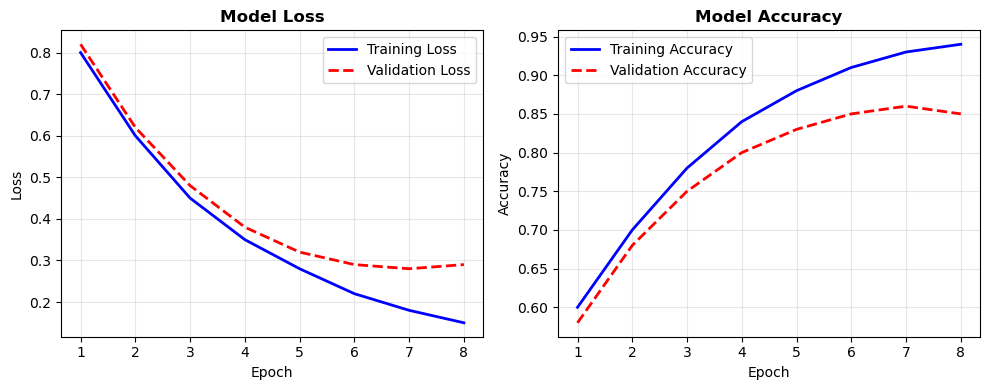

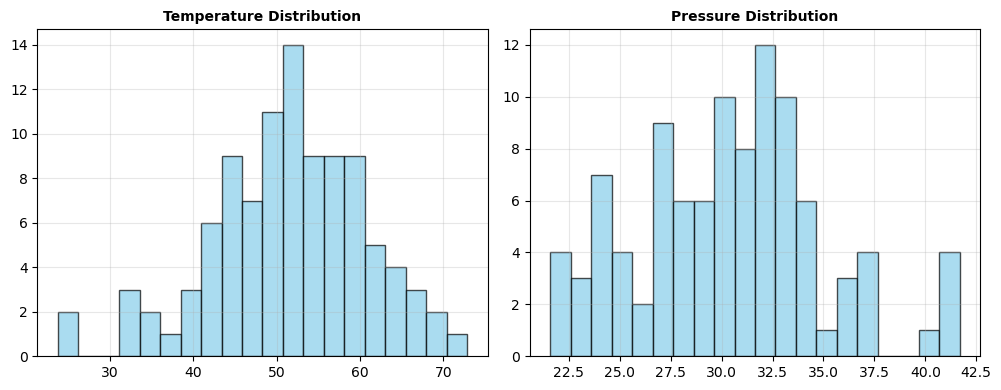

✅ Visualizations created successfully using our ai_utils package!


In [10]:
# Simulating ai_utils/visualization.py
# Visualization utilities for ML experiments

import matplotlib.pyplot as plt

class MLVisualizer:
    """Visualization tools for machine learning workflows."""
    
    @staticmethod
    def plot_training_history(history, figsize=(10, 4)):
        """Plot training loss and accuracy curves."""
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # Loss curve
        epochs = range(1, len(history['loss']) + 1)
        axes[0].plot(epochs, history['loss'], 'b-', label='Training Loss', linewidth=2)
        if 'val_loss' in history:
            axes[0].plot(epochs, history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
        axes[0].set_title('Model Loss', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Accuracy curve
        if 'accuracy' in history:
            axes[1].plot(epochs, history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
            if 'val_accuracy' in history:
                axes[1].plot(epochs, history['val_accuracy'], 'r--', label='Validation Accuracy', linewidth=2)
            axes[1].set_title('Model Accuracy', fontsize=12, fontweight='bold')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Accuracy')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    @staticmethod
    def plot_feature_distribution(data, feature_names=None, bins=20):
        """Plot distribution of features."""
        n_features = len(data[0]) if isinstance(data[0], (list, tuple)) else 1
        
        if n_features == 1:
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.hist(data, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
            ax.set_title('Feature Distribution', fontsize=12, fontweight='bold')
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.grid(True, alpha=0.3)
        else:
            fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 4))
            if n_features == 1:
                axes = [axes]
            for i, ax in enumerate(axes):
                feature_data = [row[i] for row in data]
                ax.hist(feature_data, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
                name = feature_names[i] if feature_names else f'Feature {i+1}'
                ax.set_title(f'{name} Distribution', fontsize=10, fontweight='bold')
                ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig

# Demonstrating the visualizer
viz = MLVisualizer()

# Simulated training history
mock_history = {
    'loss': [0.8, 0.6, 0.45, 0.35, 0.28, 0.22, 0.18, 0.15],
    'val_loss': [0.82, 0.62, 0.48, 0.38, 0.32, 0.29, 0.28, 0.29],
    'accuracy': [0.6, 0.7, 0.78, 0.84, 0.88, 0.91, 0.93, 0.94],
    'val_accuracy': [0.58, 0.68, 0.75, 0.80, 0.83, 0.85, 0.86, 0.85]
}

fig1 = viz.plot_training_history(mock_history)
plt.show()

# Simulated feature data
import random
random.seed(42)
feature_data = [[random.gauss(50, 10), random.gauss(30, 5)] for _ in range(100)]
fig2 = viz.plot_feature_distribution(feature_data, feature_names=['Temperature', 'Pressure'])
plt.show()

print("✅ Visualizations created successfully using our ai_utils package!")

## 9. Running Scripts from Command Line <a name="command-line"></a>

Use `python -m` to run modules as scripts, which is essential for relative imports within packages:

In [11]:
# Command line execution examples (run in terminal):

# Run a module as a script (allows relative imports)
# python -m my_package.module_name

# Run a script directly
# python my_script.py

# Run with specific Python version
# python3.9 my_script.py

# Check module search path
import sys
print("📂 Python Module Search Path:")
for i, path in enumerate(sys.path[:5], 1):  # Show first 5 paths
    print(f"{i}. {path}")
print("...")

# Add custom path (useful in notebooks for importing local modules)
# sys.path.append('/path/to/your/module')

# Check if running as main
if __name__ == "__main__":
    print("\n💡 Tip: Use 'python -m' when your script uses relative imports within a package!")
    print("Example: python -m src.data.loaders")

📂 Python Module Search Path:
1. c:\Users\786\miniconda3\envs\env_dl\python313.zip
2. c:\Users\786\miniconda3\envs\env_dl\DLLs
3. c:\Users\786\miniconda3\envs\env_dl\Lib
4. c:\Users\786\miniconda3\envs\env_dl
5. 
...

💡 Tip: Use 'python -m' when your script uses relative imports within a package!
Example: python -m src.data.loaders


---

## 🛠️ Hands-On Exercises <a name="exercises"></a>

Complete these exercises to solidify your understanding of modules, packages, and virtual environments.

### Exercise 1: Create a Simple Module
Create a file `math_utils.py` with functions `calculate_mean()` and `calculate_std()`. Import and test them below.

In [12]:
# your code here


### Exercise 2: Import Styles
Demonstrate three different ways to import the `math` module and use `sqrt()` with each method.

In [13]:
# your code here


### Exercise 3: Use the `__name__` Guard
Write a script that prints "Running as module" when imported and "Running as main" when executed directly.

In [14]:
# your code here


### Exercise 4: Build a Small Package
Create a package structure with `mypackage/__init__.py` and `mypackage/stats.py`. The stats module should contain a function `summarize(data)` that returns min, max, mean, and std.

In [15]:
# your code here


### Exercise 5: Create requirements.txt
Write code that generates a `requirements.txt` file with at least 5 common ML packages (numpy, pandas, scikit-learn, matplotlib, tensorflow).

In [16]:
# your code here


### Exercise 6: Virtual Environment Simulation
Write a script that checks if it's running in a virtual environment and prints appropriate messages.

In [17]:
# your code here


### Exercise 7: Organize a Mini AI Project
Use `os.makedirs()` to create a complete project structure including `src/`, `data/`, `notebooks/`, `models/`, and `configs/` directories with appropriate `__init__.py` files.

In [18]:
# your code here


### Exercise 8: Write a Reusable Data Preprocessing Module
Create a module with a `DataCleaner` class that has methods for: handling missing values, removing duplicates, and scaling features. Test it with sample data.

In [19]:
# your code here


### Exercise 9: Standard Library Practice
Use `collections.Counter` to count class labels in a dataset, `random` to shuffle the data, and `datetime` to timestamp the operation.

In [20]:
# your code here


### Exercise 10: Package Configuration with `__all__`
Create a package where `__init__.py` uses `__all__` to control what gets imported with `from package import *`. Demonstrate the behavior.

In [21]:
# your code here


### Exercise 11: Visualization Utility
Create a visualization module with a function `plot_confusion_matrix()` that takes a 2x2 confusion matrix and displays it using matplotlib with proper labels and a colorbar.

In [22]:
# your code here


---

## Solutions (check after attempting) <a name="solutions"></a>

### Solution 1: Create a Simple Module

In [23]:
# Save this as 'math_utils.py' in the same directory:
math_utils_code = '''
def calculate_mean(data):
    """Calculate the arithmetic mean of a dataset."""
    if not data:
        return 0
    return sum(data) / len(data)

def calculate_std(data):
    """Calculate the standard deviation of a dataset."""
    if len(data) < 2:
        return 0
    mean = calculate_mean(data)
    variance = sum((x - mean) ** 2 for x in data) / (len(data) - 1)
    return variance ** 0.5

if __name__ == "__main__":
    test_data = [1, 2, 3, 4, 5]
    print(f"Mean: {calculate_mean(test_data)}")
    print(f"Std: {calculate_std(test_data)}")
'''

# Write the file
with open('math_utils.py', 'w') as f:
    f.write(math_utils_code)

# Import and test
import math_utils
data = [10, 20, 30, 40, 50]
print(f"Mean: {math_utils.calculate_mean(data):.2f}")
print(f"Std: {math_utils.calculate_std(data):.2f}")

# Clean up
import os
os.remove('math_utils.py')

Mean: 30.00
Std: 15.81


### Solution 2: Import Styles

In [24]:
# Method 1: Import entire module
import math
print(f"Method 1: {math.sqrt(16)}")

# Method 2: Import specific function
from math import sqrt
print(f"Method 2: {sqrt(25)}")

# Method 3: Import with alias
import math as m
print(f"Method 3: {m.sqrt(36)}")

# Expected output:
# Method 1: 4.0
# Method 2: 5.0
# Method 3: 6.0

Method 1: 4.0
Method 2: 5.0
Method 3: 6.0


### Solution 3: Use the `__name__` Guard

In [25]:
# Save as 'test_module.py'
test_module_code = '''
def greet():
    return "Hello from the module!"

if __name__ == "__main__":
    print("Running as main")
else:
    print("Running as module")
'''

with open('test_module.py', 'w') as f:
    f.write(test_module_code)

# When imported:
import test_module

# Clean up
import os
os.remove('test_module.py')

# Expected output when imported: "Running as module"
# Expected output when run directly: "Running as main"

Running as module


### Solution 4: Build a Small Package

In [26]:
import os

# Create package structure
os.makedirs('mypackage', exist_ok=True)

# Create __init__.py
with open('mypackage/__init__.py', 'w') as f:
    f.write('from .stats import summarize\n')

# Create stats.py
stats_code = '''
import math

def summarize(data):
    """Return min, max, mean, and std of data."""
    if not data:
        return None
    
    n = len(data)
    mean = sum(data) / n
    min_val = min(data)
    max_val = max(data)
    
    if n > 1:
        variance = sum((x - mean) ** 2 for x in data) / (n - 1)
        std = math.sqrt(variance)
    else:
        std = 0
    
    return {
        'min': min_val,
        'max': max_val,
        'mean': mean,
        'std': std
    }
'''

with open('mypackage/stats.py', 'w') as f:
    f.write(stats_code)

# Test the package
from mypackage import summarize
data = [12, 45, 67, 23, 89, 34]
result = summarize(data)
print(result)

# Clean up
import shutil
shutil.rmtree('mypackage')

# Expected output:
# {'min': 12, 'max': 89, 'mean': 45.0, 'std': 28.8...}

{'min': 12, 'max': 89, 'mean': 45.0, 'std': 28.684490582891655}


### Solution 5: Create requirements.txt

In [27]:
requirements_content = """# Machine Learning Dependencies
numpy>=1.21.0
pandas>=1.3.0
scikit-learn>=1.0.0
matplotlib>=3.5.0
tensorflow>=2.8.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content)

print("✅ Created requirements.txt")
with open('requirements.txt', 'r') as f:
    print(f.read())

# Clean up
import os
os.remove('requirements.txt')

# Expected: File created with 5 package entries

✅ Created requirements.txt
# Machine Learning Dependencies
numpy>=1.21.0
pandas>=1.3.0
scikit-learn>=1.0.0
matplotlib>=3.5.0
tensorflow>=2.8.0



### Solution 6: Virtual Environment Simulation

In [28]:
import sys
import os

def check_environment():
    """Check if running in a virtual environment."""
    # Check for conda environment
    if 'CONDA_DEFAULT_ENV' in os.environ:
        env_name = os.environ['CONDA_DEFAULT_ENV']
        print(f"🔬 Conda environment detected: {env_name}")
        return True
    
    # Check for venv/virtualenv
    # In a venv, sys.prefix points to the venv, sys.base_prefix to system Python
    if hasattr(sys, 'real_prefix'):
        print("🐍 Virtual environment detected (virtualenv)")
        return True
    elif hasattr(sys, 'base_prefix') and sys.base_prefix != sys.prefix:
        print(f"🐍 Virtual environment detected (venv)")
        print(f"   System Python: {sys.base_prefix}")
        print(f"   Virtual env: {sys.prefix}")
        return True
    
    print("⚠️  No virtual environment detected - using system Python")
    print(f"   Python path: {sys.executable}")
    return False

check_environment()

# Expected output depends on your current environment setup

🔬 Conda environment detected: env_dl


True

### Solution 7: Organize a Mini AI Project

In [29]:
import os

def create_ml_project(base_name="mini_ml_project"):
    """Create a complete ML project structure."""
    
    structure = {
        f"{base_name}/src": ["__init__.py", "train.py", "evaluate.py"],
        f"{base_name}/src/data": ["__init__.py", "loaders.py"],
        f"{base_name}/src/models": ["__init__.py", "network.py"],
        f"{base_name}/src/utils": ["__init__.py", "helpers.py"],
        f"{base_name}/data/raw": [],
        f"{base_name}/data/processed": [],
        f"{base_name}/notebooks": ["eda.ipynb"],
        f"{base_name}/models": [],
        f"{base_name}/configs": ["config.yaml"],
        f"{base_name}/tests": ["__init__.py", "test_models.py"]
    }
    
    created_dirs = []
    created_files = []
    
    for dir_path, files in structure.items():
        os.makedirs(dir_path, exist_ok=True)
        created_dirs.append(dir_path)
        
        for file in files:
            file_path = os.path.join(dir_path, file)
            with open(file_path, 'w') as f:
                if file == '__init__.py':
                    f.write(f'"""{os.path.basename(dir_path)} package."""\n')
                elif file.endswith('.py'):
                    f.write(f'"""{file} module."""\n')
            created_files.append(file_path)
    
    print(f"✅ Created ML project: {base_name}")
    print(f"   Directories: {len(created_dirs)}")
    print(f"   Files: {len(created_files)}")
    
    # Display tree
    for root, dirs, files in os.walk(base_name):
        level = root.replace(base_name, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 2 * (level + 1)
        for file in files:
            print(f'{subindent}{file}')
    
    # Cleanup
    import shutil
    shutil.rmtree(base_name)
    print(f"\n🧹 Cleaned up {base_name}")

create_ml_project()

# Expected: Tree structure showing all directories and files

✅ Created ML project: mini_ml_project
   Directories: 10
   Files: 13
mini_ml_project/
  configs/
    config.yaml
  data/
    processed/
    raw/
  models/
  notebooks/
    eda.ipynb
  src/
    evaluate.py
    train.py
    __init__.py
    data/
      loaders.py
      __init__.py
    models/
      network.py
      __init__.py
    utils/
      helpers.py
      __init__.py
  tests/
    test_models.py
    __init__.py

🧹 Cleaned up mini_ml_project


### Solution 8: Reusable Data Preprocessing Module

In [30]:
import os

# Create the module
os.makedirs('preprocessing', exist_ok=True)

cleaner_code = '''
class DataCleaner:
    """Handle common data cleaning tasks."""
    
    @staticmethod
    def handle_missing(data, strategy='mean'):
        """Fill missing values (None or empty strings)."""
        # Filter out None values
        clean = [x for x in data if x is not None and x != '']
        
        if strategy == 'mean' and clean:
            fill_val = sum(clean) / len(clean)
        elif strategy == 'median' and clean:
            sorted_clean = sorted(clean)
            n = len(sorted_clean)
            fill_val = sorted_clean[n//2] if n % 2 else (sorted_clean[n//2-1] + sorted_clean[n//2]) / 2
        else:
            fill_val = 0
        
        return [x if x is not None and x != '' else fill_val for x in data]
    
    @staticmethod
    def remove_duplicates(data):
        """Remove duplicate entries while preserving order."""
        seen = set()
        result = []
        for item in data:
            if item not in seen:
                seen.add(item)
                result.append(item)
        return result
    
    @staticmethod
    def min_max_scale(data):
        """Scale data to [0, 1] range."""
        if not data or max(data) == min(data):
            return data
        min_val = min(data)
        max_val = max(data)
        return [(x - min_val) / (max_val - min_val) for x in data]
'''

with open('preprocessing/cleaner.py', 'w') as f:
    f.write(cleaner_code)

with open('preprocessing/__init__.py', 'w') as f:
    f.write('from .cleaner import DataCleaner\n')

# Test the module
from preprocessing import DataCleaner

cleaner = DataCleaner()

# Test data
data = [1, 2, None, 4, 2, '', 6, None, 4]
print(f"Original: {data}")

filled = cleaner.handle_missing(data)
print(f"Filled: {filled}")

unique = cleaner.remove_duplicates(filled)
print(f"Unique: {unique}")

scaled = cleaner.min_max_scale(unique)
print(f"Scaled: {[round(x, 3) for x in scaled]}")

# Cleanup
import shutil
shutil.rmtree('preprocessing')

# Expected output showing cleaned and scaled data

Original: [1, 2, None, 4, 2, '', 6, None, 4]
Filled: [1, 2, 3.1666666666666665, 4, 2, 3.1666666666666665, 6, 3.1666666666666665, 4]
Unique: [1, 2, 3.1666666666666665, 4, 6]
Scaled: [0.0, 0.2, 0.433, 0.6, 1.0]


### Solution 9: Standard Library Practice

In [31]:
from collections import Counter
import random
import datetime

# Sample dataset with class labels
dataset = [
    {'features': [1, 2], 'label': 'cat'},
    {'features': [2, 3], 'label': 'dog'},
    {'features': [1, 1], 'label': 'cat'},
    {'features': [3, 2], 'label': 'bird'},
    {'features': [2, 2], 'label': 'cat'},
    {'features': [3, 3], 'label': 'dog'},
    {'features': [1, 3], 'label': 'bird'},
]

# Count labels using Counter
labels = [item['label'] for item in dataset]
label_counts = Counter(labels)
print(f"📊 Class distribution: {dict(label_counts)}")

# Shuffle dataset using random
random.seed(42)  # For reproducibility
shuffled_indices = list(range(len(dataset)))
random.shuffle(shuffled_indices)
shuffled_data = [dataset[i] for i in shuffled_indices]

print(f"\n🔀 First item after shuffle: {shuffled_data[0]}")

# Timestamp the operation
timestamp = datetime.datetime.now()
print(f"\n⏰ Operation completed at: {timestamp.strftime('%Y-%m-%d %H:%M:%S')}")

# Expected output:
# Class distribution: {'cat': 3, 'dog': 2, 'bird': 2}
# First item after shuffle: (varies by seed)
# Operation completed at: (current time)

📊 Class distribution: {'cat': 3, 'dog': 2, 'bird': 2}

🔀 First item after shuffle: {'features': [2, 3], 'label': 'dog'}

⏰ Operation completed at: 2026-03-25 06:36:02


### Solution 10: Package Configuration with `__all__`

In [32]:
import os

# Create package
os.makedirs('mytools', exist_ok=True)

# Create __init__.py with __all__
init_content = '''
from .math_tools import add, multiply
from .string_tools import capitalize

__all__ = ['add', 'capitalize']  # Only these will be imported with *
# 'multiply' is available but not included in *
'''

with open('mytools/__init__.py', 'w') as f:
    f.write(init_content)

# Create math_tools.py
math_content = '''
def add(a, b):
    return a + b

def multiply(a, b):
    return a * b
'''

with open('mytools/math_tools.py', 'w') as f:
    f.write(math_content)

# Create string_tools.py
string_content = '''
def capitalize(text):
    return text.capitalize()

def reverse(text):
    return text[::-1]
'''

with open('mytools/string_tools.py', 'w') as f:
    f.write(string_content)

# Demonstrate the effect of __all__
print("Testing 'from mytools import *':")
exec('''
from mytools import *
print(f"  add(2,3) = {add(2, 3)}")  # Should work
print(f"  capitalize('hello') = {capitalize('hello')}")  # Should work
try:
    print(f"  multiply(2,3) = {multiply(2, 3)}")  # Won't be imported with *
except NameError as e:
    print(f"  ❌ multiply not available via *: {e}")
''')

print("\nBut explicit import still works:")
from mytools import multiply
print(f"  multiply(2,3) = {multiply(2, 3)}")

# Cleanup
import shutil
shutil.rmtree('mytools')

# Expected: add and capitalize work with *, multiply requires explicit import

Testing 'from mytools import *':
  add(2,3) = 5
  capitalize('hello') = Hello
  ❌ multiply not available via *: name 'multiply' is not defined

But explicit import still works:
  multiply(2,3) = 6


### Solution 11: Visualization Utility

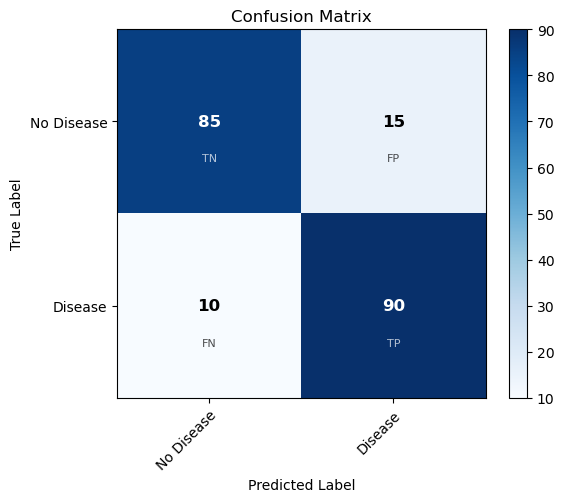

✅ Confusion matrix plotted successfully!
   Accuracy: 87.50%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, class_names=None, figsize=(6, 5), cmap='Blues'):
    """
    Plot a 2x2 confusion matrix.
    
    Args:
        cm: 2x2 confusion matrix [[TN, FP], [FN, TP]]
        class_names: List of class names [Negative, Positive]
        figsize: Figure size tuple
        cmap: Colormap name
    """
    if class_names is None:
        class_names = ['Negative', 'Positive']
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    
    # Set ticks
    ax.set(xticks=[0, 1],
           yticks=[0, 1],
           xticklabels=class_names,
           yticklabels=class_names,
           title='Confusion Matrix',
           ylabel='True Label',
           xlabel='Predicted Label')
    
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add text annotations
    thresh = np.array(cm).max() / 2.
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i][j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i][j] > thresh else "black",
                    fontsize=12, fontweight='bold')
    
    # Add labels for each quadrant
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i+0.2, labels[i][j],
                    ha="center", va="center",
                    color="white" if cm[i][j] > thresh else "black",
                    fontsize=8, alpha=0.7)
    
    fig.tight_layout()
    return fig

# Test with sample confusion matrix
# Format: [[True Negative, False Positive],
#          [False Negative, True Positive]]
sample_cm = [[85, 15],   # 85 TN, 15 FP
             [10, 90]]   # 10 FN, 90 TP

fig = plot_confusion_matrix(sample_cm, class_names=['No Disease', 'Disease'])
plt.show()

print("✅ Confusion matrix plotted successfully!")
print(f"   Accuracy: {(sample_cm[0][0] + sample_cm[1][1]) / sum(sum(row) for row in sample_cm):.2%}")

# Expected: A 2x2 heatmap with values 85, 15, 10, 90 and colorbar